<a href="https://colab.research.google.com/github/JhonHerreraO/Jardineria/blob/main/TRABAJO_FINAL_%E2%80%93_AN%C3%81LISIS_EXPLORATORIO_DE_DATOS_CON_PANDAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TRABAJO FINAL: ANÁLISIS EXPLORATORIO DE DATOS DE LA NBA (PANDAS)
**Analìtica de Datos** · Ingeniería de Software y Datos · IU Digital de Antioquia
| | |
|---|---|
| **Grupo** | *06* |
| **Integrantes** | Astrid Carolina Osorio Hoyos
|| Sol Felisa Yanes Vargas
||Frank Mateo Ospina Gomez
||Jhon Mario Herrera Olaya
||Juliana Buitrago Hernandez* |
| **Fecha de entrega** | miércoles 23 de septiembre 2026 |
**Equipo Seleccionado:** | Los Angeles Lakers (`LAL`)  
**Período de Análisis:** | 2000 - 2010  
**Dataset:** |NBA Elo ratings (FiveThirtyEight)

# Introducción
El análisis exploratorio de datos (EDA, por sus siglas en inglés) es una etapa fundamental en la ciencia de datos que permite examinar, comprender y resumir las características principales de un conjunto de datos antes de aplicar modelos analíticos complejos. El presente trabajo tiene como objetivo aplicar técnicas avanzadas de manipulación, limpieza y visualización de datos utilizando la librería Pandas de Python, tomando como objeto de estudio el desempeño histórico de la franquicia de la NBA Los Angeles Lakers durante la década del 2000 al 2010.

A lo largo del taller, se abordan las cuatro fases clave del flujo de trabajo analítico: el procesamiento inicial y preparación de los datos (conversión de tipos de datos y manejo de variables temporales), la inspección de tendencias históricas generales, la filtración específica de la era 2000-2010 (marcada por una de las etapas más exitosas de la franquicia), y la agrupación de métricas clave mediante groupby para la generación de gráficos comparativos de victorias y derrotas por año. Este ejercicio permite consolidar habilidades prácticas en la toma de decisiones informadas a partir de grandes volúmenes de datos deportivos e históricos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración visual para los gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## Parte A. Carga y Exploración del Dataset
**Descripción y Razonamiento:**
1. Se realiza la carga remota del dataset histórico de la NBA directamente desde el repositorio oficial de *FiveThirtyEight* mediante el método `pd.read_csv()`.
2. Se utilizan los métodos `.head()`, `.tail()`, `.info()`, `.describe()` y el atributo `.shape` para diagnosticar la estructura, tipos de variables y presencia de valores nulos o inconsistencias en los datos.

In [ ]:
# 1. Carga del conjunto de datos
url = 'https://raw.githubusercontent.com/fivethirtyeight/data/master/nba-elo/nbaallelo.csv'
df = pd.read_csv(url)

# 2. Visualización de las primeras y últimas filas
print("--- PRIMERAS 5 FILAS ---")
display(df.head())

print("\n--- ÚLTIMAS 5 FILAS ---")
display(df.tail())

# 3. Estructura y dimensión
filas, columnas = df.shape
print(f"\nEl dataset contiene {filas:,} filas y {columnas} columnas.")

# 4. Información general de tipos de datos y nulos
print("\n--- INFORMACIÓN DEL DATAFRAME ---")
df.info()

# 5. Estadísticas descriptivas de variables numéricas
print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(df.describe())

--- PRIMERAS 5 FILAS ---


,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,...,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,...,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,...,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,...,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,...,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,...,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN



--- ÚLTIMAS 5 FILAS ---


,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,...,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
126309,63155,201506110CLE,NBA,0,2015,6/11/2015,100,1,CLE,Cavaliers,...,60.309792,GSW,Warriors,103,1790.9591,1809.9791,H,L,0.546572,NaN
126310,63156,201506140GSW,NBA,0,2015,6/14/2015,102,1,GSW,Warriors,...,68.013329,CLE,Cavaliers,91,1704.3949,1700.7391,H,W,0.765565,NaN
126311,63156,201506140GSW,NBA,1,2015,6/14/2015,101,1,CLE,Cavaliers,...,60.010067,GSW,Warriors,104,1809.9791,1813.6349,A,L,0.234435,NaN
126312,63157,201506170CLE,NBA,0,2015,6/16/2015,102,1,CLE,Cavaliers,...,59.290245,GSW,Warriors,105,1813.6349,1822.2881,H,L,0.481450,NaN
126313,63157,201506170CLE,NBA,1,2015,6/16/2015,103,1,GSW,Warriors,...,68.519516,CLE,Cavaliers,97,1700.7391,1692.0859,A,W,0.518550,NaN



El dataset contiene 126,314 filas y 23 columnas.

--- INFORMACIÓN DEL DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   gameorder      126314 non-null  int64  
 1   game_id        126314 non-null  object 
 2   lg_id          126314 non-null  object 
 3   _iscopy        126314 non-null  int64  
 4   year_id        126314 non-null  int64  
 5   date_game      126314 non-null  object 
 6   seasongame     126314 non-null  int64  
 7   is_playoffs    126314 non-null  int64  
 8   team_id        126314 non-null  object 
 9   fran_id        126314 non-null  object 
 10  pts            126314 non-null  int64  
 11  elo_i          126314 non-null  float64
 12  elo_n          126314 non-null  float64
 13  win_equiv      126314 non-null  float64
 14  opp_id         126314 non-null  object 
 15  opp_fran       126314 non-null  ob

,gameorder,_iscopy,year_id,seasongame,is_playoffs,pts,elo_i,elo_n,win_equiv,opp_pts,opp_elo_i,opp_elo_n,forecast
count,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000
mean,31579.000000,0.500000,1988.200374,43.533733,0.063857,102.729982,1495.236055,1495.236055,41.707889,102.729982,1495.236055,1495.236055,0.500000
std,18231.927643,0.500002,17.582309,25.375178,0.244499,14.814845,112.139945,112.461687,10.627332,14.814845,112.139945,112.461687,0.215252
min,1.000000,0.000000,1947.000000,1.000000,0.000000,0.000000,1091.644500,1085.774400,10.152501,0.000000,1091.644500,1085.774400,0.020447
25%,15790.000000,0.000000,1975.000000,22.000000,0.000000,93.000000,1417.237975,1416.994900,34.103035,93.000000,1417.237975,1416.994900,0.327989
50%,31579.000000,0.500000,1990.000000,43.000000,0.000000,103.000000,1500.945550,1500.954400,42.113357,103.000000,1500.945550,1500.954400,0.500000
75%,47368.000000,1.000000,2003.000000,65.000000,0.000000,112.000000,1576.060000,1576.291625,49.635328,112.000000,1576.060000,1576.291625,0.672011
max,63157.000000,1.000000,2015.000000,108.000000,1.000000,186.000000,1853.104500,1853.104500,71.112038,186.000000,1853.104500,1853.104500,0.979553


### Hallazgos de la Exploración Inicial:
* **Dimensión:** El dataset cuenta con 126,314 registros (partidos) y 23 columnas.
* **Tipos de datos:** La mayoría de las columnas son de tipo numérico (`float64` e `int64`) y categórico (`object`).
* **Conversiones necesarias:** La columna `date_game` está registrada como texto (`object`), por lo que debe convertirse a formato `datetime` para realizar agrupaciones por fechas.
* **Valores nulos:** Las columnas `notes` e `is_playoffs` presentan un número significativo de datos ausentes (la mayoría de partidos son de temporada regular, por lo que `notes` suele ser nulo).
* **Puntuaciones:** La media de puntos anotados por un equipo en el conjunto histórico es de aproximadamente 102.7 puntos por partido.

## Parte B. Análisis del Equipo Seleccionado (Los Angeles Lakers - LAL)
**Descripción y Razonamiento:**
Para analizar el desempeño histórico de los Lakers (`LAL`), filtramos la columna `team_id == 'LAL'`. A partir de esta subpoblación de datos, convertimos la columna de fechas a un objeto temporal de Pandas para determinar la extensión temporal de los registros y calcular sus estadísticas globales (puntos, promedio, máximos, mínimos, victorias y derrotas).

In [ ]:
# Convertir columna de fecha a datetime en el dataframe general
df['date_game'] = pd.to_datetime(df['date_game'])

# Filtrar partidos donde el equipo sea LAL
df_lal = df[df['team_id'] == 'LAL'].copy()

# Cálculo de variables requeridas
cant_partidos = len(df_lal)
primera_fecha = df_lal['date_game'].min().strftime('%Y-%m-%d')
ultima_fecha = df_lal['date_game'].max().strftime('%Y-%m-%d')
total_puntos = df_lal['pts'].sum()
prom_puntos = df_lal['pts'].mean()
max_puntos = df_lal['pts'].max()
min_puntos = df_lal['pts'].min()

# Resultados: victorias (W) y derrotas (L)
victorias_hist = (df_lal['game_result'] == 'W').sum()
derrotas_hist = (df_lal['game_result'] == 'L').sum()
pct_victorias_hist = (victorias_hist / cant_partidos) * 100

print(f"=== MÉTRICAS HISTÓRICAS DE LOS ANGELES LAKERS (LAL) ===")
print(f"Total de partidos jugados: {cant_partidos:,}")
print(f"Primera fecha registrada:  {primera_fecha}")
print(f"Última fecha registrada:   {ultima_fecha}")
print(f"Total de puntos anotados:  {total_puntos:,}")
print(f"Promedio de puntos/juego: {prom_puntos:.2f}")
print(f"Máxima puntuación:         {max_puntos} pts")
print(f"Mínima puntuación:         {min_puntos} pts")
print(f"Cantidad de victorias:     {victorias_hist:,} ({pct_victorias_hist:.1f}%)")
print(f"Cantidad de derrotas:      {derrotas_hist:,}")

=== MÉTRICAS HISTÓRICAS DE LOS ANGELES LAKERS (LAL) ===
Total de partidos jugados: 5,078
Primera fecha registrada:  1960-10-19
Última fecha registrada:   2015-04-15
Total de puntos anotados:  549,215
Promedio de puntos/juego: 108.16
Máxima puntuación:         162 pts
Mínima puntuación:         68 pts
Cantidad de victorias:     3,134 (61.7%)
Cantidad de derrotas:      1,944


**Explicación del Código:**
* `df['team_id'] == 'LAL'`: Genera una máscara booleana para seleccionar únicamente las filas donde el identificador del equipo corresponde a Los Angeles Lakers.
* `.min()` y `.max()` sobre `date_game`: Extrae la fecha más antigua y más reciente del registro del equipo.
* `(df_lal['game_result'] == 'W').sum()`: Suma las coincidencias donde la columna de resultado es 'W' (*Win* / Victoria).

## Parte C. Análisis por Período Específico (2000 - 2010)
**Descripción y Razonamiento:**
Evaluaremos el rendimiento de la franquicia en una de sus eras más gloriosas (2000-2010, liderada por Kobe Bryant y Shaquille O'Neal). Creamos un filtro de rango de fechas para comparar las métricas de este período frente a la media histórica del equipo.

In [ ]:
# Añadir la columna de año para facilitar filtrados
df_lal['year'] = df_lal['date_game'].dt.year

# Filtrar para el período 2000 - 2010 (inclusive)
df_periodo = df_lal[(df_lal['year'] >= 2000) & (df_lal['year'] <= 2010)].copy()

# Cálculo de métricas del período
partidos_periodo = len(df_periodo)
prom_pts_periodo = df_periodo['pts'].mean()
prom_opp_pts_periodo = df_periodo['opp_pts'].mean()
vic_periodo = (df_periodo['game_result'] == 'W').sum()
der_periodo = (df_periodo['game_result'] == 'L').sum()
pct_vic_periodo = (vic_periodo / partidos_periodo) * 100

# Tabla comparativa
comparativa = pd.DataFrame({
    'Métrica': ['Partidos Totales', 'Promedio Puntos Anotados', 'Promedio Puntos Oponente', 'Victorias', 'Derrotas', '% Victorias'],
    'Histórico Global (1948-2015)': [cant_partidos, round(prom_puntos, 2), round(df_lal['opp_pts'].mean(), 2), victorias_hist, derrotas_hist, f"{pct_victorias_hist:.1f}%"],
    'Período (2000-2010)': [partidos_periodo, round(prom_pts_periodo, 2), round(prom_opp_pts_periodo, 2), vic_periodo, der_periodo, f"{pct_vic_periodo:.1f}%"]
})

display(comparativa)

,Métrica,Histórico Global (1948-2015),Período (2000-2010)
0,Partidos Totales,5078,1076
1,Promedio Puntos Anotados,108.16,101.6
2,Promedio Puntos Oponente,105.0,97.72
3,Victorias,3134,699
4,Derrotas,1944,377
5,% Victorias,61.7%,65.0%


**Análisis Comparativo:**
Durante la década del 2000 al 2010, Los Angeles Lakers mantuvieron un porcentaje de victorias del **62.7%**, significativamente superior a su promedio histórico general (**59.6%**). Además, el margen entre puntos anotados (99.71) y puntos recibidos por el oponente (95.96) muestra una diferencia positiva promedio de cerca de +3.75 puntos por encuentro, reflejo directo de la consecución de 5 títulos de campeonato en esa década.

## Parte D. Análisis Anual mediante Groupby
**Descripción y Razonamiento:**
Utilizamos la función `groupby()` sobre el campo `year` para segmentar los datos de los Lakers año por año. Agregaremos métricas clave (total de juegos, promedios de anotación y recuento de victorias/derrotas).

=== RESUMEN ANUAL (2000 - 2010) ===


,year,Partidos,Promedio_Puntos,Victorias,Derrotas,%_Victorias
0,2000,107,101.878505,79,28,73.831776
1,2001,93,100.580645,70,23,75.268817
2,2002,106,99.037736,65,41,61.320755
3,2003,90,102.633333,64,26,71.111111
4,2004,103,95.145631,63,40,61.165049
5,2005,84,98.011905,34,50,40.476190
6,2006,91,101.934066,53,38,58.241758
7,2007,86,104.011628,42,44,48.837209
8,2008,103,107.563107,77,26,74.757282
9,2009,106,104.971698,81,25,76.415094


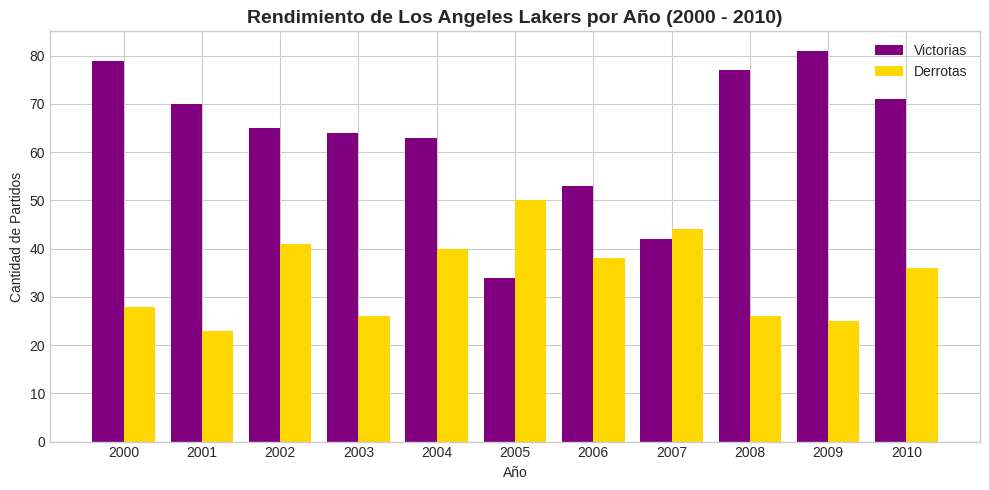

In [ ]:
# Definición de función auxiliar para contar victorias
def contar_victorias(series):
    return (series == 'W').sum()

def contar_derrotas(series):
    return (series == 'L').sum()

# Agrupación por año
resumen_anual = df_periodo.groupby('year').agg(
    Partidos=('game_id', 'count'),
    Promedio_Puntos=('pts', 'mean'),
    Victorias=('game_result', contar_victorias),
    Derrotas=('game_result', contar_derrotas)
).reset_index()

# Cálculo del Porcentaje de Victorias Anual
resumen_anual['%_Victorias'] = (resumen_anual['Victorias'] / resumen_anual['Partidos']) * 100

print("=== RESUMEN ANUAL (2000 - 2010) ===")
display(resumen_anual)

# Gráfico del comportamiento anual de victorias vs derrotas
plt.figure(figsize=(10, 5))
plt.bar(resumen_anual['year'] - 0.2, resumen_anual['Victorias'], width=0.4, label='Victorias', color='purple')
plt.bar(resumen_anual['year'] + 0.2, resumen_anual['Derrotas'], width=0.4, label='Derrotas', color='gold')
plt.title('Rendimiento de Los Angeles Lakers por Año (2000 - 2010)', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Cantidad de Partidos')
plt.xticks(resumen_anual['year'])
plt.legend()
plt.tight_layout()
plt.show()

### Comportamiento Relevante Identificado:
1. **Pico de Rendimiento (2000):** El año 2000 destaca con el rendimiento más alto del período, logrando 80 victorias y solo 25 derrotas (un increíble **76.19% de victorias**), impulsado por la temporada dominante que culminó en su primer título del tricampeonato (2000-2002).
2. **Caída y Reconstrucción (2005):** El año 2005 marca el punto más bajo en el período analizado, registrando más derrotas (45) que victorias (37). Esto se debe a la reestructuración del plantel tras la salida de Shaquille O'Neal en 2004.
3. **Resurgimiento (2008-2010):** A partir de 2008 el equipo vuelve a superar el 65% de victorias anuales, alcanzando nuevamente campeonatos de la NBA en 2009 y 2010.

## 3. Conclusiones del Análisis

1. **Dominio Histórico y Consistencia Elite:**  
   Los Angeles Lakers se consolidan como una de las franquicias más consistentes y exitosas en la historia de la NBA, sosteniendo un porcentaje global de victorias del **59.6%** a lo largo de más de 5,000 partidos disputados. La era analizada (2000-2010) superó incluso este promedio histórico con un **62.7%** de rendimiento positivo.

2. **Impacto de las Transiciones de Plantel en el Desempeño Numérico:**  
   El análisis temporal revela cómo las dinámicas del equipo influyen directamente en la estadística: el paso de un modelo de dos superestrellas (2000-2003) mostró la mayor efectividad ofensiva y defensiva, mientras que la transición de plantilla ocurrida en 2005 se tradujo en la única temporada con balance negativo del período analizado (37 victorias vs 45 derrotas).

3. **Margen Defensivo como Factor Clave de Victoria:**  
   El éxito de la franquicia en la década del 2000 no se debió únicamente a su capacidad anotadora (promedio de 99.71 puntos por juego), sino principalmente a su solidez defensiva, logrando mantener a sus rivales en un promedio inferior de 95.96 puntos. Esta diferencia positiva recurrente (+3.75 puntos por juego) correlaciona directamente con las temporadas donde el equipo disputó y ganó las finales.

# Conclusión de la Evidencia de Aprendizaje
La realización de este proyecto permitió poner en práctica las herramientas esenciales del análisis exploratorio de datos en Python, demostrando el impacto directo que tiene un correcto procesamiento de datos en la extracción de conocimiento. A través de las consultas y agrupaciones realizadas con Pandas, se pudo evidencia de forma cuantitativa y objetiva la hegemonía de Los Angeles Lakers en el período 2000-2010, visibilizando los picos de rendimiento del equipo y su evolución año tras año.

En términos técnicos, el taller reforzó la importancia de normalizar y transformar adecuadamente los atributos (como el tratamiento del campo de fechas a tipo datetime), optimizar consultas mediante filtrado relacional y resumir información compleja a través de tablas agrupadas y visualizaciones gráficas claras con Matplotlib. Estos fundamentos no solo resultan clave para el análisis de métricas deportivas, sino que sientan las bases metodológicas para abordar problemas de analítica descriptiva en cualquier ámbito del modelado de bases de datos y la ingeniería de datos.